# 05 — Neural network: EnergyMLP (PyTorch)
**EM 630 · Electricity Demand Forecasting · Phase 6**

**Question.** Can a multilayer perceptron, trained by gradient descent, match the tree ensembles (**≈ 51.7 MW**)?

**Experiments**: v1–v3 exactly as in the project brief, plus one of ours:

| | Architecture | Training | Purpose |
|---|---|---|---|
| v1 | [64, 32], dropout 0.1 | Adam lr 1e-3, batch 256 | small network |
| v2 | [256, 128, 64], dropout 0.3 | Adam lr 1e-3, batch 256 | more capacity + more regularisation |
| v3 | as v2 | **lr 1e-4, batch 512** | learning-rate / batch tuning |
| v4 (ours) | best of v1–v3 on Val | **predict the hourly change** | carries over the Phase 5 finding |

**Expectations written down before running**
1. v2's extra capacity helps only if dropout keeps it from overfitting.
2. A smaller learning rate converges more slowly but more smoothly.
3. The Δ-target helps the MLP as it helped the trees.

In [1]:
import sys, json, inspect, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
from IPython.display import Image, display
from src import config, data, features, split, mlp
pd.set_option("display.precision", 3)
def show(name, width=1000):
    display(Image(filename=str(config.FIG_DIR / f"{name}.png"), width=width))
sp = split.chronological_split(features.build_features(data.load_clean()))
F = features.FEATURE_SETS["mlp"]
print(f"{len(F)} input features (same full-rank set as the linear models)")

47 input features (same full-rank set as the linear models)


---
## 1. The network and how it learns

In [2]:
print(inspect.getsource(mlp.EnergyMLP))
print(mlp.EnergyMLP(len(F), [256, 128, 64], 0.3))

class EnergyMLP(nn.Module):
    def __init__(self, n_in: int, hidden: list[int], dropout: float):
        super().__init__()
        layers, d = [], n_in
        for h in hidden:
            layers += [nn.Linear(d, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            d = h
        layers.append(nn.Linear(d, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

EnergyMLP(
  (net): Sequential(
    (0): Linear(in_features=47, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, 

| Component | What it does | Course concept |
|---|---|---|
| `Linear` | $h = Wx + b$ | the parameters learned by gradient descent |
| `BatchNorm1d` | re-centres and re-scales each layer's activations per mini-batch | stabilises and speeds up optimisation |
| `ReLU` | $\max(0, z)$ | the non-linearity; without it the network collapses to one linear model |
| `Dropout(p)` | randomly zeroes a fraction $p$ of units during training | regularisation (a noisy ensemble of sub-networks) |
| `weight_decay=1e-4` in Adam | adds $\lambda\|W\|_2^2$ to the loss | **L2 regularisation**, Ridge for networks |
| **Adam** | gradient descent with momentum and per-parameter step sizes | the optimiser |
| **ReduceLROnPlateau** | halves the learning rate when validation loss stalls | step-size schedule |
| **Early stopping** | stop after `patience` epochs without improvement; restore the best weights | the number of epochs acts as a regularisation hyperparameter |

In [3]:
print(inspect.getsource(mlp.MLPForecaster.fit))

    def fit(self, train_df: pd.DataFrame, val_df: pd.DataFrame):
        """Train with early stopping on val_df. Shuffling happens WITHIN the training rows only
        (mini-batch SGD); the chronological split between train and val is untouched."""
        t0 = time.time()
        self._prep(train_df)
        Xtr, ytr = self._tensors(train_df)
        Xva, yva = self._tensors(val_df)
        m, opt = self._new_model()
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=self.cfg.lr_factor,
                                                           patience=self.cfg.lr_patience, min_lr=self.cfg.min_lr)
        gen = torch.Generator().manual_seed(self.seed)
        best, best_state, best_ep, wait = np.inf, None, 0, 0
        hist = []
        for ep in range(1, self.cfg.max_epochs + 1):
            lr_used = opt.param_groups[0]["lr"]
            tr = self._epoch(m, opt, Xtr, ytr, gen)
            va = self._eval_loss(m, Xva, yva)
            sched.step(va)
            

**Shuffling and leakage.** Mini-batches are shuffled *within the training rows* (that is what makes it stochastic gradient descent). It doesn't break the chronological split: Train, Val and Test remain separate blocks in time, and each row's features already encode its own past.

**Test protocol, the same as every other model.** After early stopping on Val, the network is **refit from scratch on Train+Val**, replaying exactly the recorded number of epochs and learning-rate schedule:

In [4]:
print(inspect.getsource(mlp.MLPForecaster.refit_replay))

    def refit_replay(self, dev_df: pd.DataFrame, schedule: list[float]):
        """Retrain from scratch on dev_df for len(schedule) epochs, using exactly those learning
        rates. Nothing from the test period is used, and no early stopping is needed."""
        self._prep(dev_df)
        X, y = self._tensors(dev_df)
        m, opt = self._new_model()
        gen = torch.Generator().manual_seed(self.seed)
        for lr in schedule:
            for g in opt.param_groups:
                g["lr"] = lr
            self._epoch(m, opt, X, y, gen)
        self.model_ = m
        self.best_epoch_ = len(schedule)
        return self



---
## 2. Training curves

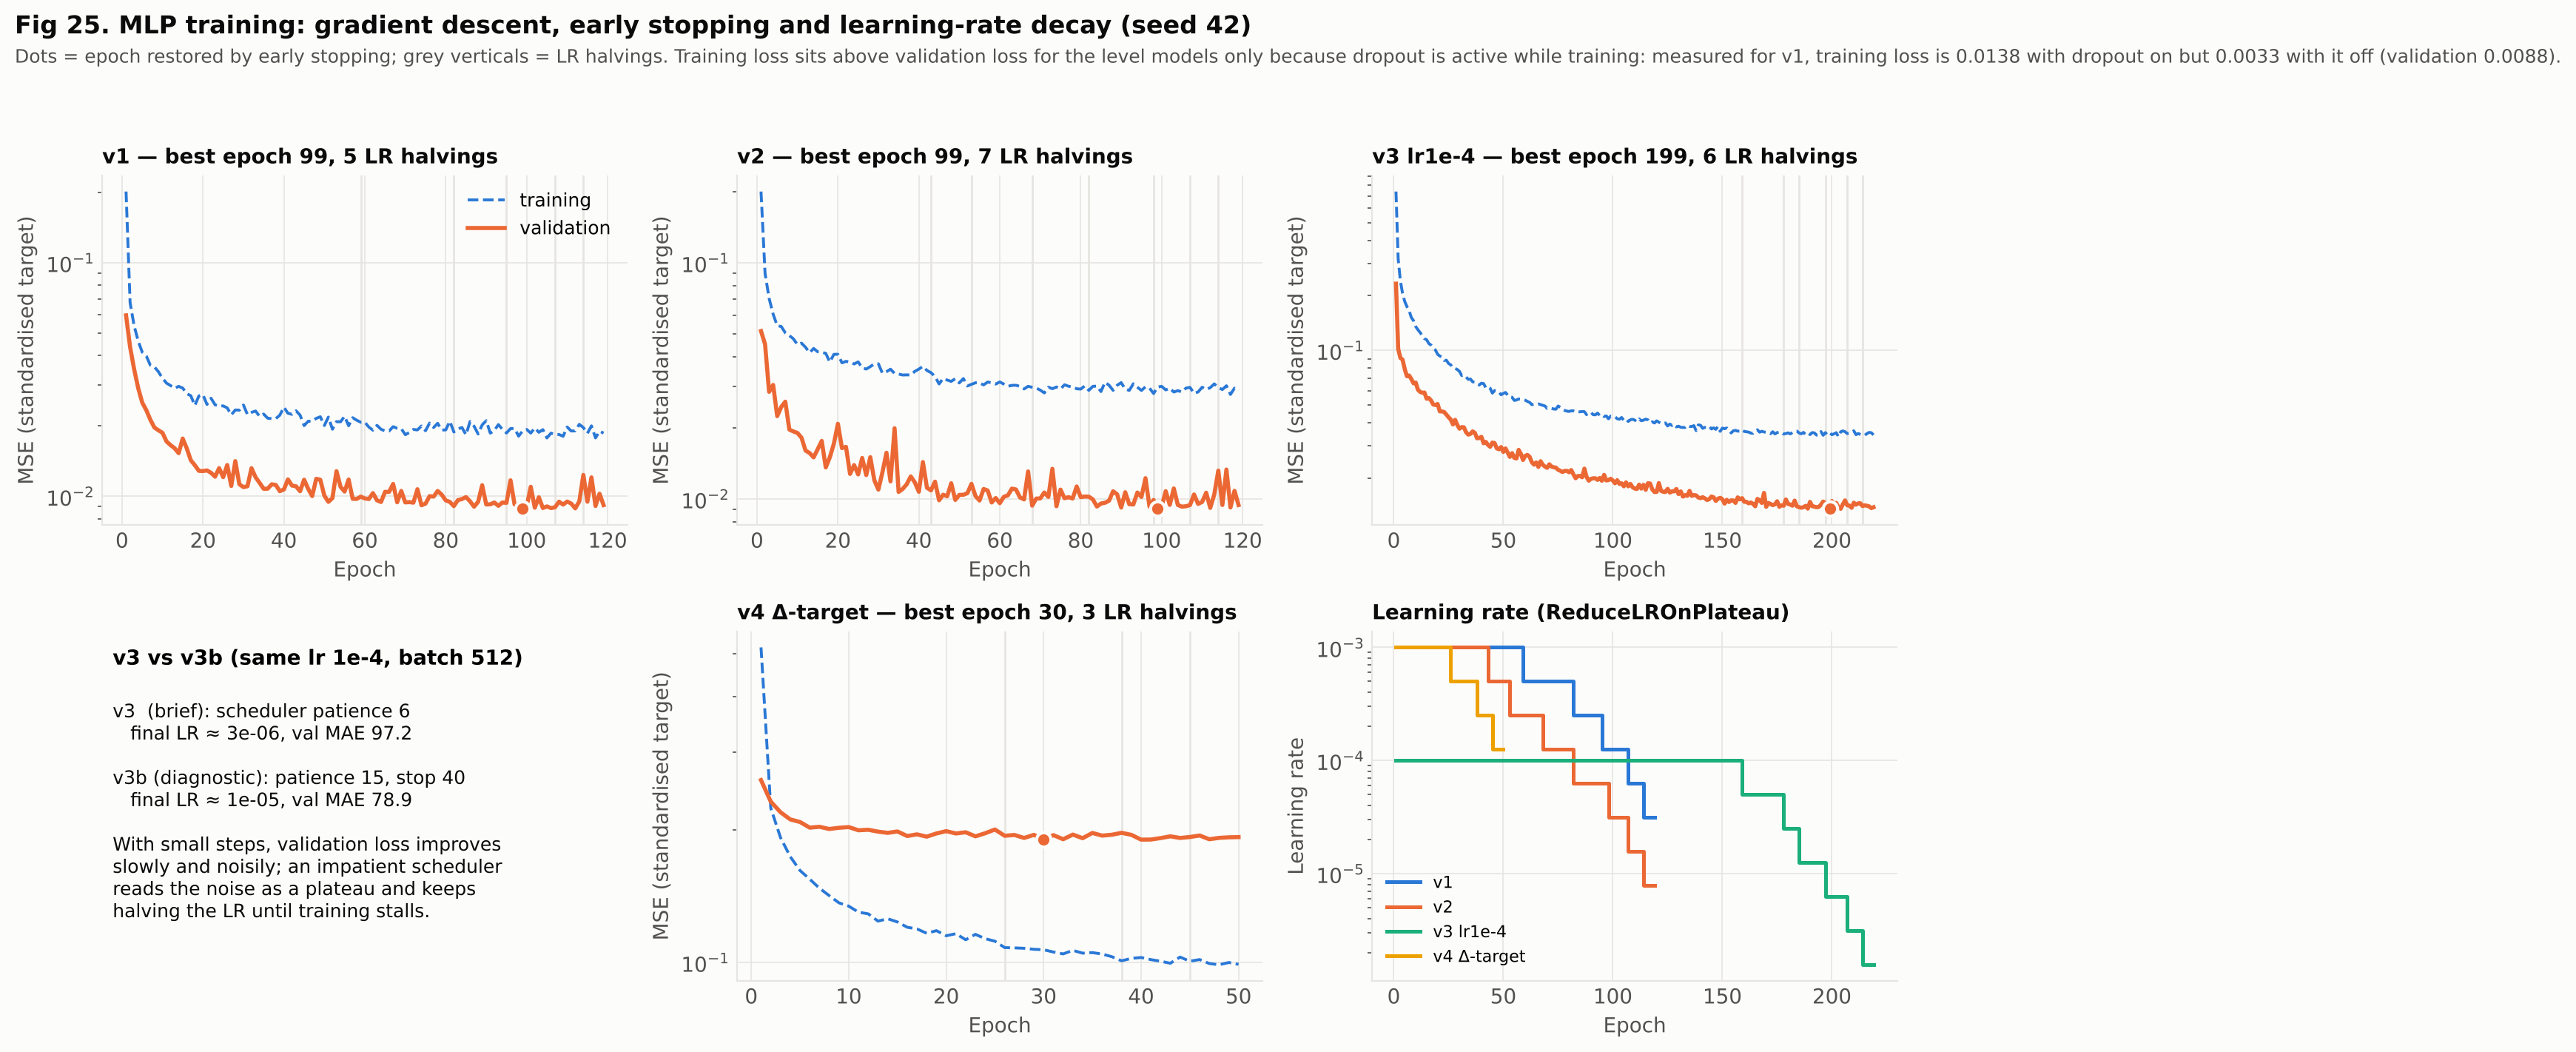

In [5]:
show("F25_mlp_training_curves", 1100)

💡 **Reading the curves**
- Each epoch is a full pass of mini-batch gradient descent. The validation curve is what early stopping watches; the dot marks the restored epoch.
- **Learning-rate halvings** (grey lines) cause the small steps down in the curves: smaller steps let the optimiser settle into a narrower valley.
- For the level models, training loss sits **above** validation loss. That isn't a bug: dropout is active while training and is switched off for evaluation. Measured: v1's training loss is 0.0138 with dropout on and 0.0033 with it off, below validation (0.0088).

---
## 3. Results: seeds, ensembles and selection

Each configuration ran with 3 random seeds. A neural network's result depends on its random initialisation and mini-batch order, so one lucky seed proves nothing. The reported model is the **3-seed ensemble** (average prediction). The configuration carried forward is chosen on **Val**, not on test.

In [6]:
seeds = pd.read_csv(config.TABLE_DIR / "phase6_seed_results.csv")
seeds.groupby("model")[["best_epoch", "final_lr", "val_MAE", "test_MAE"]].agg(["mean", "std"]).round(3)

best_epoch         final_lr      val_MAE  \
                                          mean     std     mean  std    mean   
model                                                                          
MLP v1 [64,32]                          90.000  14.731      0.0  0.0  71.338   
MLP v2 [256,128,64]                     90.333  10.970      0.0  0.0  71.778   
MLP v3 [256,128,64] lr1e-4             201.333  17.616      0.0  0.0  97.162   
MLP v3b [256,128,64] lr1e-4 patient    364.000  47.624      0.0  0.0  78.920   
MLP v4 [64,32] Δ-target                 40.333   8.963      0.0  0.0  61.574   

                                           test_MAE         
                                       std     mean    std  
model                                                       
MLP v1 [64,32]                       0.964   62.362  4.063  
MLP v2 [256,128,64]                  0.416   63.877  4.866  
MLP v3 [256,128,64] lr1e-4           3.083   91.143  8.929  
MLP v3b [256,128,64] lr1e-4 patient  4.145   65.035  4.340  
MLP v4 [64,32] Δ-target              0.391   53.255  0.368

In [7]:
meta = json.load(open(config.TABLE_DIR / "phase6_meta.json"))
print("Selected on Val:", meta["selected_on_val"])
tab = pd.read_csv(config.TABLE_DIR / "phase6_mlp.csv")
cols = ["model", "MAE", "RMSE", "MAPE", "R2", "Bias", "skill_vs_step", "skill_vs_xgb"]
for s in ["val", "test"]:
    print(f"\n{s.upper()}")
    display(tab[(tab.split == s) & (tab.subset == "all")][cols].sort_values("MAE").reset_index(drop=True))

Selected on Val: MLP v4 [64,32] Δ-target

VAL


,model,MAE,RMSE,MAPE,R2,Bias,skill_vs_step,skill_vs_xgb
0,Random Forest,58.827,116.656,1.199,0.990,0.435,3.752e-01,0.005
1,XGBoost,59.121,116.466,1.204,0.990,0.618,3.721e-01,0.000
2,"MLP v4 [64,32] Δ-target",60.088,117.864,1.234,0.990,-1.951,3.618e-01,-0.016
3,"MLP v1 [64,32]",67.437,122.426,1.397,0.989,3.118,2.837e-01,-0.141
4,"MLP v2 [256,128,64]",69.103,125.677,1.431,0.989,-2.682,2.660e-01,-0.169
5,"MLP v3b [256,128,64] lr1e-4 patient",76.223,134.504,1.567,0.987,6.112,1.904e-01,-0.289
6,Lasso + hour×month,77.142,129.126,1.604,0.988,3.848,1.807e-01,-0.305
7,Naive-1 + hourly step,94.152,147.221,1.984,0.984,0.650,0.000e+00,-0.593
8,"MLP v3 [256,128,64] lr1e-4",94.189,156.253,1.938,0.982,5.095,-4.000e-04,-0.593
9,Naive-1 (persistence),192.433,253.084,3.953,0.953,1.020,-1.044e+00,-2.255



TEST


,model,MAE,RMSE,MAPE,R2,Bias,skill_vs_step,skill_vs_xgb
0,XGBoost,51.734,76.165,1.204,0.997,1.125,0.304,0.000
1,Random Forest,51.908,76.432,1.208,0.997,1.098,0.301,-0.003
2,"MLP v4 [64,32] Δ-target",52.123,76.369,1.215,0.997,1.753,0.299,-0.007
3,"MLP v1 [64,32]",56.001,78.857,1.291,0.996,10.859,0.246,-0.083
4,"MLP v2 [256,128,64]",60.551,83.659,1.414,0.996,10.039,0.185,-0.170
5,"MLP v3b [256,128,64] lr1e-4 patient",62.113,87.368,1.454,0.996,9.174,0.164,-0.201
6,Lasso + hour×month,64.913,92.030,1.558,0.995,5.077,0.127,-0.255
7,Naive-1 + hourly step,74.313,104.284,1.774,0.994,2.158,0.000,-0.436
8,"MLP v3 [256,128,64] lr1e-4",86.620,116.657,2.014,0.992,25.993,-0.166,-0.674
9,Naive-1 (persistence),204.685,265.201,5.055,0.959,0.424,-1.754,-2.957


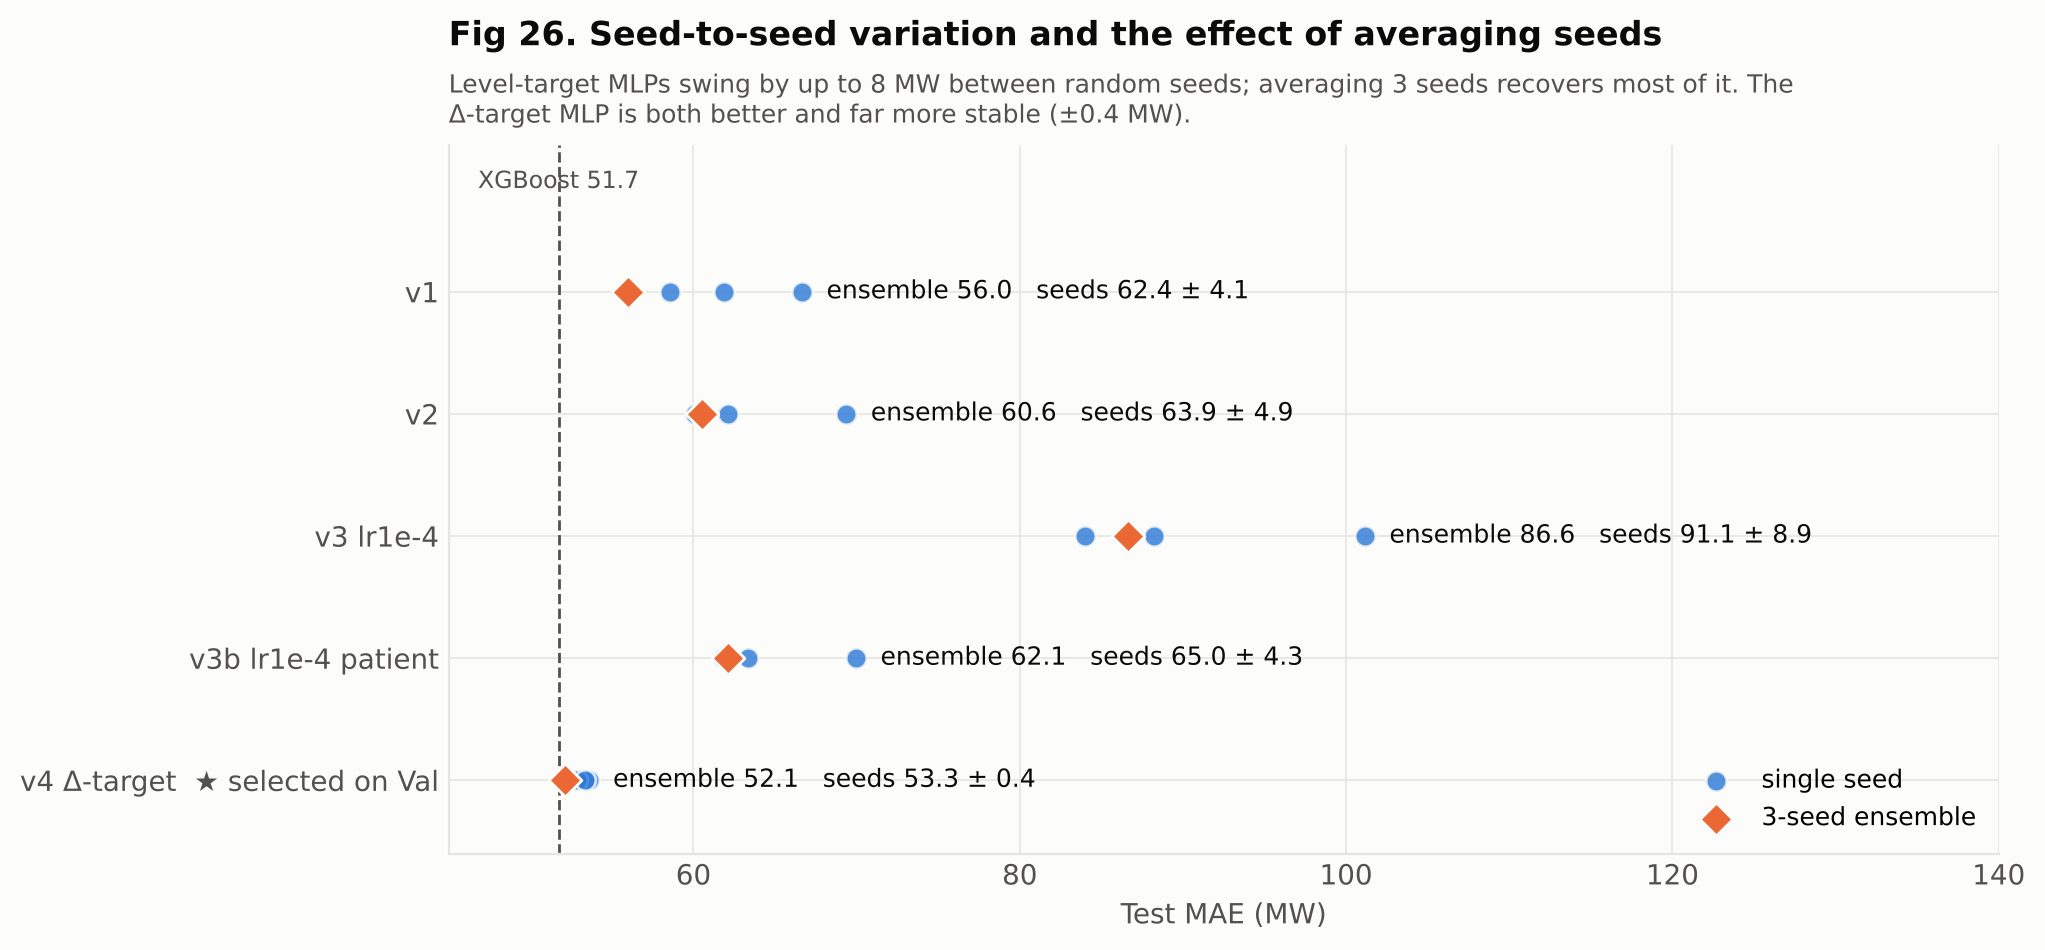

In [8]:
show("F26_mlp_seed_variance")

---
## 4. Two evaluator follow-ups

**(a) Was v3 bad because of lr = 1e-4, or because of the scheduler?** v3's learning rate was halved six times, to about $10^{-6}$, before it converged. With small steps, validation loss improves slowly and noisily, and ReduceLROnPlateau mistakes the noise for a plateau. **v3b** keeps v3's lr and batch size but uses a patient scheduler:

In [9]:
seeds[seeds.model.str.contains("v3")][["model", "seed", "best_epoch", "final_lr", "val_MAE", "test_MAE"]]

,model,seed,best_epoch,final_lr,val_MAE,test_MAE
6,"MLP v3 [256,128,64] lr1e-4",42,199,6.250e-06,93.909,84.014
7,"MLP v3 [256,128,64] lr1e-4",7,220,1.000e-06,100.040,101.158
8,"MLP v3 [256,128,64] lr1e-4",2026,185,3.125e-06,97.537,88.257
12,"MLP v3b [256,128,64] lr1e-4 patient",42,310,6.250e-06,83.465,69.966
13,"MLP v3b [256,128,64] lr1e-4 patient",7,400,1.250e-05,75.347,63.344
14,"MLP v3b [256,128,64] lr1e-4 patient",2026,382,1.250e-05,77.949,61.797


✅ Both effects are real. The patient scheduler recovers most of the loss (Val ≈ 97 → 79 MW), so **v3 was mostly starved by the schedule**. Even so, lr 1e-4 still trails v1's lr 1e-3 (Val ≈ 71): with this data and budget, the larger step size wins.

**(b) Does the Train+Val refit help or hurt the MLP?** We compared each seed's Train-only early-stopped model with its refit version, both scored on test:

In [10]:
rv = pd.read_csv(config.TABLE_DIR / "phase6_refit_variance.csv")
display(rv.round(1))
rv.groupby("model")[["test_MAE_train_only", "test_MAE_refit"]].agg(["mean", "std"]).round(1)

,model,seed,test_MAE_train_only,test_MAE_refit
0,"MLP v1 [64,32]",42,58.4,58.6
1,"MLP v1 [64,32]",7,59.4,61.9
2,"MLP v1 [64,32]",2026,62.3,66.7
3,"MLP v4 [64,32] Δ-target",42,53.6,53.6
4,"MLP v4 [64,32] Δ-target",7,51.8,52.9
5,"MLP v4 [64,32] Δ-target",2026,52.3,53.3


test_MAE_train_only      test_MAE_refit     
                                       mean  std           mean  std
model                                                               
MLP v1 [64,32]                         60.0  2.0           62.4  4.1
MLP v4 [64,32] Δ-target                52.6  0.9           53.3  0.4

✅ For the MLP, the refit **slightly hurts**: it replays the epoch count but cannot "restore the best epoch", so it ends on noisier weights (v1's seed spread doubles). For v4 the cost is ≈ 0.7 MW. **We keep the protocol anyway**, because every model is treated identically and changing the protocol after seeing test scores would be test-set leakage. It goes in the report as a small, known disadvantage for the MLP.

---
## 5. Peak hours

In [11]:
tab[(tab.split == "test") & (tab.subset == "peak")][["model", "n", "MAE", "MAPE", "Bias"]].sort_values("MAE").reset_index(drop=True)

,model,n,MAE,MAPE,Bias
0,Random Forest,588,52.951,0.811,4.434
1,XGBoost,588,53.652,0.821,8.023
2,"MLP v4 [64,32] Δ-target",588,53.753,0.823,4.816
3,Lasso + hour×month,588,62.664,0.955,24.643
4,Naive-1 + hourly step,588,66.256,1.014,8.615
5,"MLP v1 [64,32]",588,67.541,1.033,28.840
6,"MLP v3b [256,128,64] lr1e-4 patient",588,75.724,1.155,42.694
7,"MLP v2 [256,128,64]",588,91.888,1.397,73.326
8,"MLP v3 [256,128,64] lr1e-4",588,122.425,1.863,100.785
9,Naive-1 (persistence),588,193.482,2.954,46.694


⚠️ The **level-target** MLPs under-forecast peaks badly (v2 bias ≈ +73 MW, v3 ≈ +101 MW): they shrink toward typical load levels. The Δ-target MLP removes this (bias ≈ +5 MW), the same pattern we saw with the trees.

---
## 6. Summary

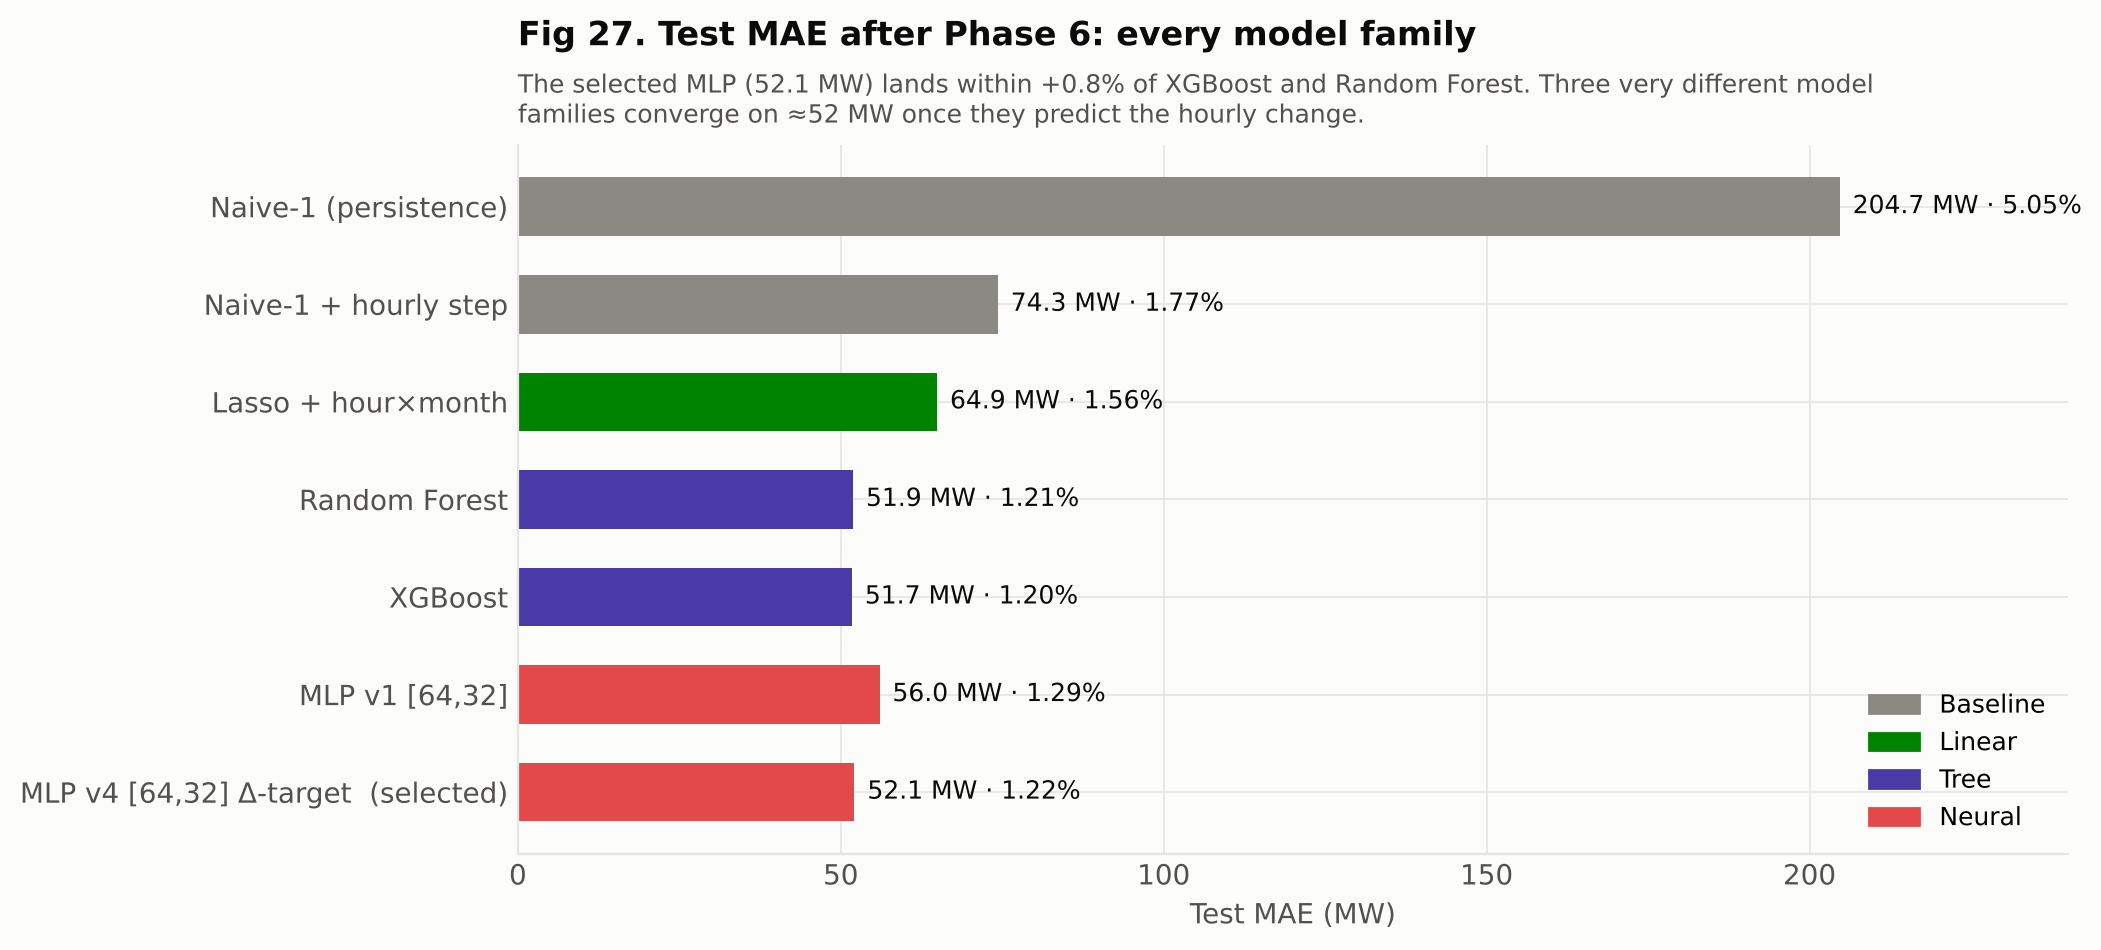

In [12]:
show("F27_results_after_mlp")

| Expectation | Result |
|---|---|
| 1. v2's capacity helps only if dropout prevents overfitting | ✘ v2 (60.6) did **not** beat v1 (56.0); the extra capacity bought nothing here |
| 2. Smaller learning rate converges more slowly but more smoothly | ◐ slower ✔, but it ended **worse**, partly because of the scheduler (v3b) |
| 3. Δ-target helps the MLP as it helped the trees | ✔ 56.0 → **52.1 MW**, seed spread ±4.1 → **±0.4** |

**Takeaways for the report**
1. The selected MLP (v4, **52.1 MW**) is within **0.8%** of XGBoost (51.7) and Random Forest (51.9). Three very different model families converge on ≈ 52 MW once they predict the hourly change, which suggests we are near what these features can explain.
2. **The target formulation mattered more than the architecture**, for the networks as it did for the trees.
3. Seed variance is real for neural networks; report ensembles or mean ± std, never a single run.